# Защита персональных данных клиентов

Вам нужно защитить данные клиентов страховой компании «Хоть потоп». Разработайте такой метод преобразования данных, чтобы по ним было сложно восстановить персональную информацию. Обоснуйте корректность его работы.

Нужно защитить данные, чтобы при преобразовании качество моделей машинного обучения не ухудшилось. Подбирать наилучшую модель не требуется.

## Загрузка данных

In [1]:
# Библиотеки 

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv('/datasets/insurance.csv')

print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Пол                5000 non-null   int64  
 1   Возраст            5000 non-null   float64
 2   Зарплата           5000 non-null   float64
 3   Члены семьи        5000 non-null   int64  
 4   Страховые выплаты  5000 non-null   int64  
dtypes: float64(2), int64(3)
memory usage: 195.4 KB
None
   Пол  Возраст  Зарплата  Члены семьи  Страховые выплаты
0    1     41.0   49600.0            1                  0
1    0     46.0   38000.0            1                  1
2    0     29.0   21000.0            0                  0
3    0     21.0   41700.0            2                  0
4    1     28.0   26100.0            0                  0


In [3]:
print (df['Страховые выплаты'].value_counts()) 
print ('----------------------------------------------------------')
print (df['Члены семьи'].value_counts())
print ('----------------------------------------------------------')
print (df['Пол'].value_counts())

0    4436
1     423
2     115
3      18
4       7
5       1
Name: Страховые выплаты, dtype: int64
----------------------------------------------------------
1    1814
0    1513
2    1071
3     439
4     124
5      32
6       7
Name: Члены семьи, dtype: int64
----------------------------------------------------------
0    2505
1    2495
Name: Пол, dtype: int64


AxesSubplot(0.125,0.125;0.775x0.755)
----------------------------------------------------------


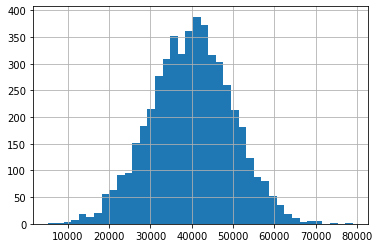

In [4]:
print(df['Зарплата'].hist(bins = 40))

AxesSubplot(0.125,0.125;0.775x0.755)


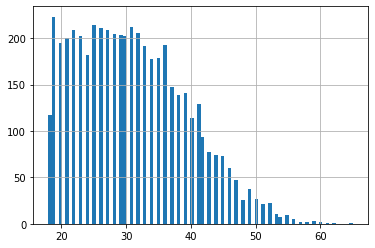

In [5]:
print(df['Возраст'].hist(bins = 90))

После первичного осмотра данных можно сделать ряд выводов - в данных нет пропусков, в данных относительно пола отсуствует дисбаланс, данные по зарплатам нормально распределены. 

## Умножение матриц

Обозначения:

- $X$ — матрица признаков (нулевой столбец состоит из единиц)

- $y$ — вектор целевого признака

- $P$ — матрица, на которую умножаются признаки

- $w$ — вектор весов линейной регрессии (нулевой элемент равен сдвигу)

Предсказания:

$$
a = Xw
$$

Задача обучения:

$$
w = \arg\min_w MSE(Xw, y)
$$

Формула обучения:

$$
w = (X^T X)^{-1} X^T y
$$

**Ответ:** не изменится

**Обоснование:** 


Cвойство обратной матрицы:
$$
(AB)^{-1} = B^{-1} A^{-1}
$$
Свойство транспорнированной матрицы:
$$
(AB)^T = B^T A^T
$$


Заменим $XP$ на $Z$:

$$
a_1 = Zw_1
$$
$$
w_1 = (Z^T Z)^{-1} Z^T y 
$$
$$
a_1 = Z (Z^T Z)^{-1} Z^T y   
$$
Заменим $Z$ на $XP$:
$$
a_1 = XP ((XP)^T (XP))^{-1} (XP)^T y 
$$
$$
a_1 = XP ((XP)^T (XP))^{-1} (XP)^T y = XP(P^T X^T XP)^{-1} P^T X^T y = XPP^{-1}(P^T X^T X)^{-1} ((XP)^T)^{-1} P^T X^T y  
$$
$$
a_1 = XE(X^T X)^{-1} (P^T)^{-1} P^T X^T y = X(X^T X)^{-1} E X^T y = X(X^T X)^{-1} X^T y  
$$
$$
a_1 = X(X^T X)^{-1} X^T y = Xw = a
$$
$$
a_1 = a
$$
q.e.d

## Алгоритм преобразования

**Алгоритм**

Для шифрования матрицы целевых признаков умножим ее на обратимую матрицу **P**, сгенерированную случайным образом. Сгенерированная матрица должна быть квадратной с ненулевым детерминантом. После чего фишруем признаки, перемножая их на данную матрицу. В конце алгоритма проводится сверка метрик R2 дабы убедиться, что результаты работы модели не задеты фишрованием

**Обоснование**

Как было пояснено ранее, умножение матрицы признаков на обратимую матрицу не меняет качество модели (линейной регрессии). 

## Проверка алгоритма

In [6]:
# Делим признаки на целевые и не целевые 
features = df.drop('Страховые выплаты',axis=1)
target = df['Страховые выплаты']

In [7]:
# Делим выборку
features_train, features_test, target_train, target_test = train_test_split(
    features, target, test_size=0.25, random_state=12345)

In [8]:
# Возьмем за основу линейную регрессию
model = LinearRegression()
model.fit(features_train, target_train)
R2_1 = r2_score(target_test, model.predict(features_test))
print("R2 =", R2_1)

R2 = 0.43522757127026546


In [9]:
# Напишем функцию шифрования данных 
def cryptic(features):
    crypted_features = features
    n = features.shape[1]
    np.random.seed(12345)
    crypted_matrix = np.random.randint(1, 10, (n,n))
    det = np.linalg.det(crypted_matrix)
    while det == 0:
        np.random.seed(12345)
        crypted_matrix = np.random.randint(1, 10, (n,n))
        det = np.linalg.det(crypted_matrix)
    crypted_features = crypted_features @ crypted_matrix
    return crypted_features, crypted_matrix

In [10]:
# Сравним данные
display(features.head())
crypted_features, crypted_matrix = cryptic(features)
display(crypted_features.head())
crypted_matrix

,Пол,Возраст,Зарплата,Члены семьи
0,1,41.0,49600.0,1
1,0,46.0,38000.0,1
2,0,29.0,21000.0,0
3,0,21.0,41700.0,2
4,1,28.0,26100.0,0


,0,1,2,3
0,99452.0,396931.0,347287.0,49899.0
1,76279.0,304140.0,266095.0,38329.0
2,42174.0,168087.0,147058.0,21203.0
3,83532.0,333667.0,291948.0,41861.0
4,52371.0,208890.0,182758.0,26301.0


array([[3, 6, 2, 5],
       [6, 3, 2, 7],
       [2, 8, 7, 1],
       [3, 2, 3, 7]])

In [11]:
# Делим выборку для зашифрованных данных
crypted_features_train, crypted_features_test, target_train, target_test = train_test_split(
    crypted_features, target, test_size=0.25, random_state=12345)

In [13]:
# Линейная регресссия для зашифрованных данных 
model = LinearRegression()
model.fit(crypted_features_train, target_train)
R2_2 = r2_score(target_test, model.predict(crypted_features_test))
print("R2 =", R2_2)
print("R2 =", R2_1)

R2 = 0.43522757127030764
R2 = 0.43522757127026546


После первичной проверки данных и доказательства, что умножение матрицы признаков на обратимую матррицу P качество модели не изменится был выведен алгоритм шифрования признаков - нахождение обратимой матрицы подходящего размера. Моедль была сначала протестирована для не шифрованных признаков, после чего была протестирована для зашифрованных признаков. R2 score полностью совпал. 